1. Loading data from SQLite database...
2. Setting up chart styles and folders...
3. Generating Chart 1: Default Rate by Grade...


C:\Users\KAPOOR\AppData\Local\Temp\ipykernel_65472\2884761171.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grade', y='target', data=grade_defaults, palette='Reds')


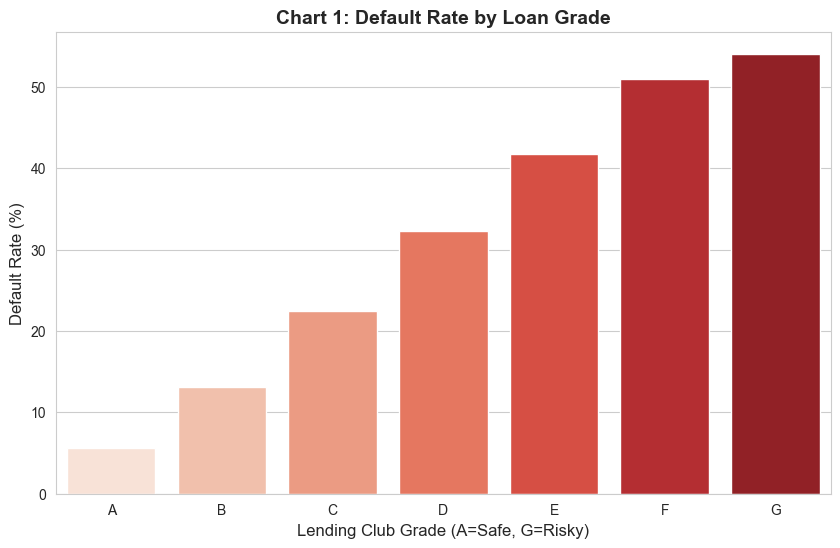

4. Generating Chart 2: Interest Rate Distribution...


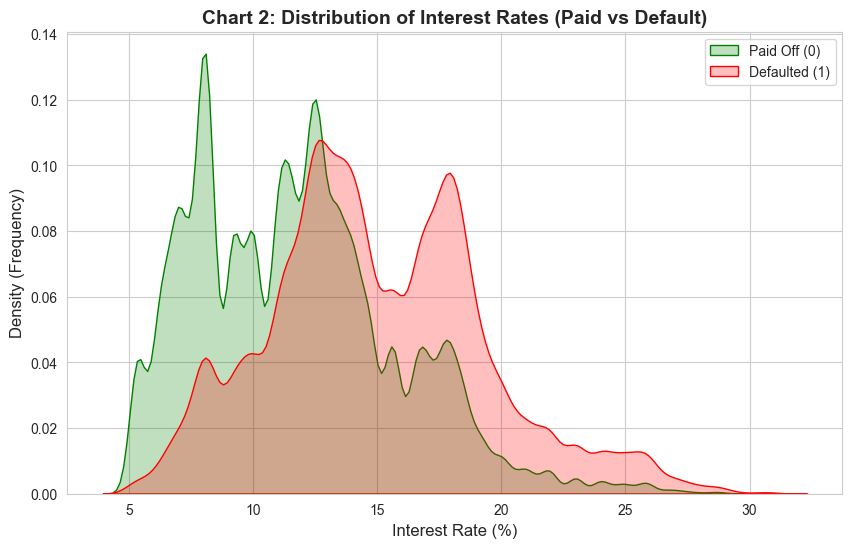

5. Generating Chart 3: Loan Amount by Default Status...


C:\Users\KAPOOR\AppData\Local\Temp\ipykernel_65472\2884761171.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='loan_amnt', data=df, palette=['#2ecc71', '#e74c3c'])


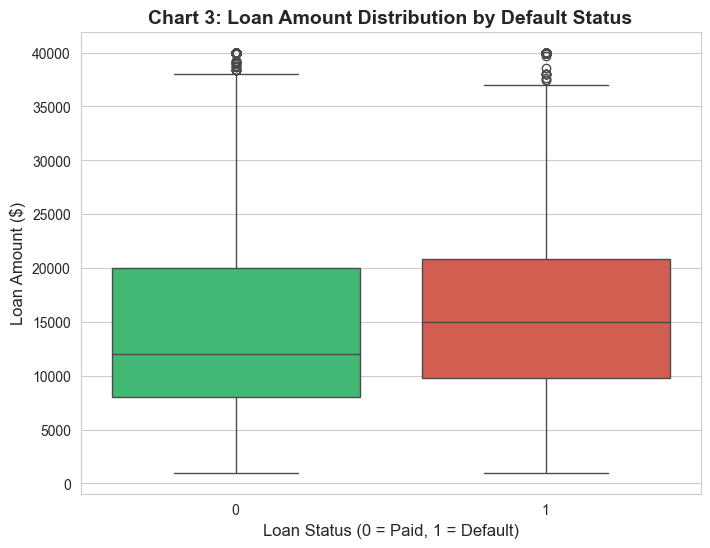

6. Generating Chart 4: Default Rate by Top 10 Purposes...


C:\Users\KAPOOR\AppData\Local\Temp\ipykernel_65472\2884761171.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='target', y='purpose', data=purpose_defaults, palette='magma')


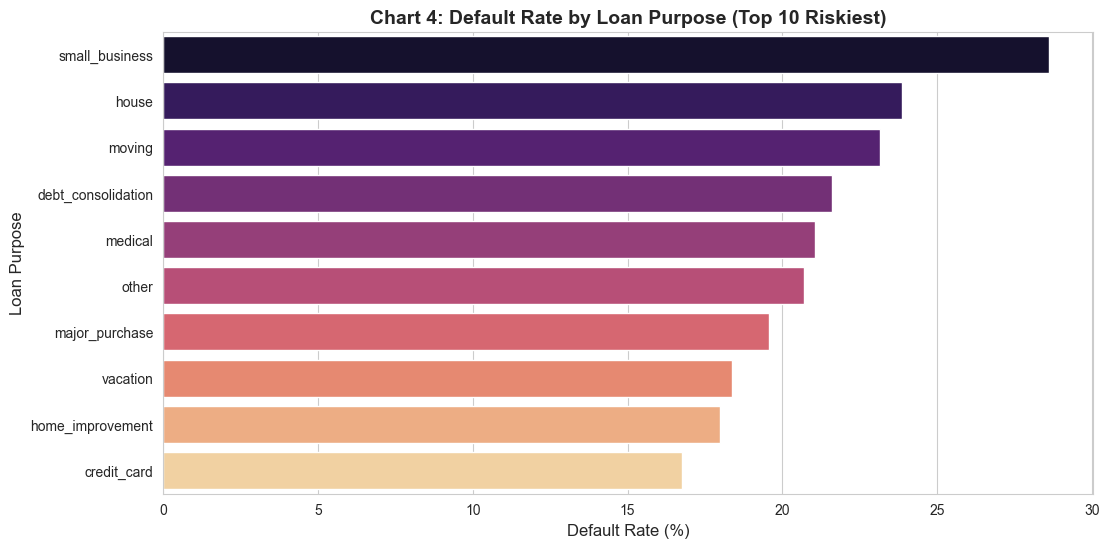

7. Generating Chart 5: Correlation Heatmap...


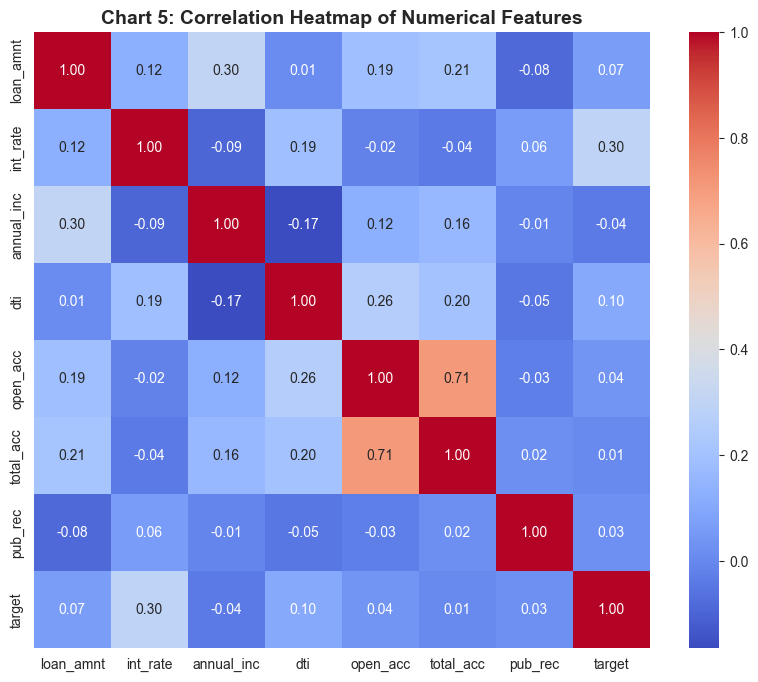

8. Generating Chart 6: Default Rate by Term...


C:\Users\KAPOOR\AppData\Local\Temp\ipykernel_65472\2884761171.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='term', y='target', data=term_defaults, palette='Blues_r')


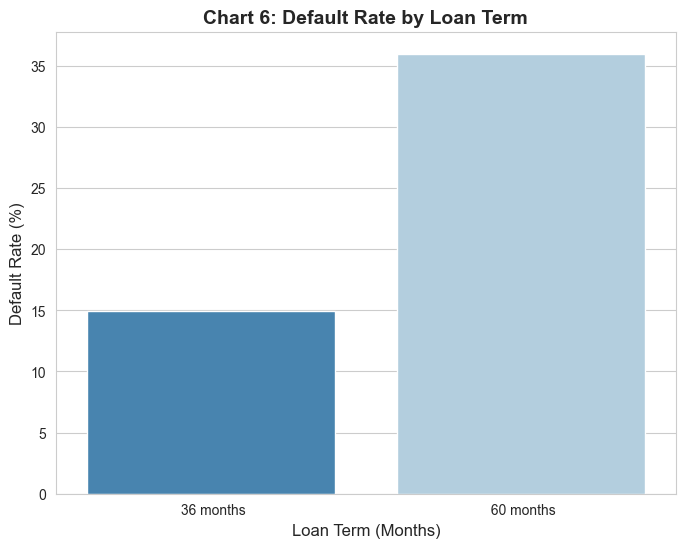


Phase 3 Complete! All 6 charts saved in the 'notebooks/images/' folder.


In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

print("1. Loading data from SQLite database...")
# Connect to our database and load the data
conn = sqlite3.connect('../data/processed/lending_club.db')
df = pd.read_sql_query("SELECT * FROM loans", conn)
conn.close()

print("2. Setting up chart styles and folders...")
# Create a folder to save our PNG files
os.makedirs('images', exist_ok=True)
# Apply a clean, professional background style to all charts
sns.set_style("whitegrid")

# ---------------------------------------------------------
print("3. Generating Chart 1: Default Rate by Grade...")
plt.figure(figsize=(10, 6))
# Calculate default rate (mean of target) for each grade
grade_defaults = df.groupby('grade')['target'].mean().reset_index()
grade_defaults['target'] *= 100 # Convert to percentage

sns.barplot(x='grade', y='target', data=grade_defaults, palette='Reds')
plt.title('Chart 1: Default Rate by Loan Grade', fontsize=14, fontweight='bold')
plt.xlabel('Lending Club Grade (A=Safe, G=Risky)', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.savefig('images/chart1_grade_default.png', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
print("4. Generating Chart 2: Interest Rate Distribution...")
plt.figure(figsize=(10, 6))
# KDE plot shows the smoothed distribution (bell curve shape) of interest rates
sns.kdeplot(data=df[df['target'] == 0], x='int_rate', label='Paid Off (0)', fill=True, color='green')
sns.kdeplot(data=df[df['target'] == 1], x='int_rate', label='Defaulted (1)', fill=True, color='red')

plt.title('Chart 2: Distribution of Interest Rates (Paid vs Default)', fontsize=14, fontweight='bold')
plt.xlabel('Interest Rate (%)', fontsize=12)
plt.ylabel('Density (Frequency)', fontsize=12)
plt.legend()
plt.savefig('images/chart2_interest_dist.png', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
print("5. Generating Chart 3: Loan Amount by Default Status...")
plt.figure(figsize=(8, 6))
# Boxplot shows the median, quartiles, and outliers of loan amounts
sns.boxplot(x='target', y='loan_amnt', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Chart 3: Loan Amount Distribution by Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Loan Status (0 = Paid, 1 = Default)', fontsize=12)
plt.ylabel('Loan Amount ($)', fontsize=12)
plt.savefig('images/chart3_loan_amount.png', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
print("6. Generating Chart 4: Default Rate by Top 10 Purposes...")
plt.figure(figsize=(12, 6))
# Calculate default rates, filter to purposes with >1000 loans, sort, and take top 10
purpose_counts = df['purpose'].value_counts()
valid_purposes = purpose_counts[purpose_counts > 1000].index
purpose_df = df[df['purpose'].isin(valid_purposes)]

purpose_defaults = purpose_df.groupby('purpose')['target'].mean().sort_values(ascending=False).head(10).reset_index()
purpose_defaults['target'] *= 100

sns.barplot(x='target', y='purpose', data=purpose_defaults, palette='magma')
plt.title('Chart 4: Default Rate by Loan Purpose (Top 10 Riskiest)', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)
plt.savefig('images/chart4_purpose_default.png', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
print("7. Generating Chart 5: Correlation Heatmap...")
plt.figure(figsize=(10, 8))
# Select only columns with numbers (no text) to find mathematical correlations
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

# Draw the heatmap with a red/blue color map
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Chart 5: Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.savefig('images/chart5_correlation.png', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
print("8. Generating Chart 6: Default Rate by Term...")
plt.figure(figsize=(8, 6))
# Group by 36 months vs 60 months
term_defaults = df.groupby('term')['target'].mean().reset_index()
term_defaults['target'] *= 100

sns.barplot(x='term', y='target', data=term_defaults, palette='Blues_r')
plt.title('Chart 6: Default Rate by Loan Term', fontsize=14, fontweight='bold')
plt.xlabel('Loan Term (Months)', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.savefig('images/chart6_term_default.png', bbox_inches='tight')
plt.show()

print("\nPhase 3 Complete! All 6 charts saved in the 'notebooks/images/' folder.")
